In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import csv
import re

In [22]:
# Read the .csv file
root = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
path = root + "experiments_s_new.csv"
path = root + "experiments0601.csv"
path = root + "experiments_0501.csv"
df = pd.read_csv(path, sep=';')
df.head(5)

,Task,Grounder,KGE,EmbedSize,WeightLoss_Task,Reasoner_depth,Model_name,Time,train_loss,train_concept_loss,...,test_concept_mrr,test_concept_hits@1@1,test_concept_hits@3@3,test_concept_hits@5@5,test_concept_hits@10@10,test_task_mrr,test_task_hits@1@1,test_task_hits@3@3,test_task_hits@5@5,test_task_hits@10@10
0,train_S1_p_no_neighbor,domain,complex,100,0.5,1,dcr,"[26.635563707351686, 1.0217642228662536]","[0.0234, 0.001]","[0.0121, 0.0008]",...,"[0.9076, 0.0274]","[0.86, 0.0358]","[0.936, 0.032]","[1.0, 0.0]","[1.0, 0.0]","[0.9082, 0.0273]","[0.86, 0.0358]","[0.936, 0.032]","[1.0, 0.0]","[1.0, 0.0]"
1,train_S1_p_no_neighbor,domain,complex,100,0.5,1,r2n,"[28.608503818511963, 0.612957713249054]","[0.0135, 0.0007]","[0.0121, 0.0008]",...,"[0.9141, 0.024]","[0.872, 0.0325]","[0.94, 0.0253]","[1.0, 0.0]","[1.0, 0.0]","[0.9145, 0.0237]","[0.872, 0.0325]","[0.94, 0.0253]","[1.0, 0.0]","[1.0, 0.0]"
2,train_S1_p_no_neighbor,domain,complex,100,0.5,1,sbr,"[19.24481921195984, 0.35983353439811294]","[0.0233, 0.0015]","[0.0159, 0.0014]",...,"[0.9288, 0.0247]","[0.9, 0.0335]","[0.94, 0.0253]","[1.0, 0.0]","[1.0, 0.0]","[0.9533, 0.0207]","[0.924, 0.0344]","[0.988, 0.016]","[1.0, 0.0]","[1.0, 0.0]"
3,train_S1_p_no_neighbor,domain,complex,100,0.5,1,rnm,"[19.387516355514528, 0.3707210398253942]","[0.0142, 0.0009]","[0.0121, 0.0008]",...,"[0.9139, 0.0168]","[0.872, 0.0204]","[0.94, 0.0253]","[1.0, 0.0]","[1.0, 0.0]","[0.9169, 0.0161]","[0.872, 0.0204]","[0.952, 0.0271]","[1.0, 0.0]","[1.0, 0.0]"
4,train_S1_p_no_neighbor,domain,complex,100,0.5,1,gsbr,"[20.168084478378297, 0.5544229949278355]","[0.0124, 0.0009]","[0.0121, 0.0008]",...,"[0.9146, 0.0234]","[0.872, 0.0325]","[0.94, 0.0253]","[1.0, 0.0]","[1.0, 0.0]","[0.915, 0.023]","[0.872, 0.0325]","[0.94, 0.0253]","[1.0, 0.0]","[1.0, 0.0]"


In [23]:
# remove the duplicates in df
df = df.drop_duplicates( keep='first')

In [24]:
for column in df:
    try:
        # For all the colum, apply eval() to convert the string to a list
        df[column] = [np.array(eval(i)) for i in df[column].values]
        
    except:
        # print("Error in ", column)
        continue

# for each col that is a string or int or object, print the unique values 
for col in df.columns:
    try: 
        if df[col].dtype == 'object' or df[col].dtype == 'int64' or df[col].dtype == 'string':
            print(df[col].unique())
            print(col)
            print()
    except:
        continue

# results = df.loc[(df['Grounder'] == 'known') & (df['KGE'] == 'distmult') & (df['EmbedSize'] == 10)]
# results

['train_S1_p_no_neighbor']
Task

['domain' 'full' 'domainbody']
Grounder

['complex' 'distmult' 'transe']
KGE

[100]
EmbedSize

[1]
Reasoner_depth

['dcr' 'r2n' 'sbr' 'rnm' 'gsbr' 'cdcr' 'no_reasoner']
Model_name



In [25]:
def split_df(df):
    # create a df that is the same as the original but with the first value of the colums in the list metrics
    df_mean = df.copy()
    for col in df_mean.columns:
        try:
            df_mean[col] = [i[0] for i in df_mean[col].values]
        except:
            continue
    # Do the same for the std
    df_std = df.copy()
    for col in df_std.columns:
        try:
            df_std[col] = [i[1] for i in df_std[col].values]
        except:
            continue
    return df_mean, df_std

# Tables

One table for the different models with KGE complex (also for the other KGEs)
Another table for the different KGEs
Another table for the time with the best model and the best KGE

In [26]:
# Table 1: rows:grounder, cols:Model, values: mrr
csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\results.csv"
cols = 'Grounder'
rows = 'Model_name'
metrics = ['test_task_mrr', 'Time']
baseline_model = 'no_reasoner'
baseline_metric = 'test_concept_mrr'
tasks = ['train_S1_p','train_S2_p','train_S3_p']
for task in tasks:
    for metric in metrics:
        for KGE in ['complex', 'distmult', 'transe']:
            print('KGE: ', KGE, ' Metric: ', metric, ' Task: ', task)
            # filter the df
            results = df.loc[ (df['Task'] == task) &(df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, test_task_mrr, test_concept_mrr
            results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
            # check if there are duplicates 
            # print(results.duplicated().sum())
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)
            if metric == 'test_task_mrr':
                # in the column no_reasoner, put the values of the column test_concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model] 

            print(results) 
            # with open(csv_dir, 'a') as f:
            #     f.write('\n Task : ,' + task + 'KGE : ,' + KGE + ', Metric: ,' + metric)
            #     f.write('\n ') 
            # results.to_csv(csv_dir, mode='a', header=True)  
results

KGE:  complex  Metric:  test_task_mrr  Task:  train_S1_p
Grounder           backward_1        backward_2        backward_3  \
Model_name                                                          
cdcr         [0.9437, 0.0354]  [0.9321, 0.0148]  [0.9321, 0.0148]   
dcr          [0.9473, 0.0255]  [0.9321, 0.0148]  [0.9321, 0.0148]   
gsbr         [0.9331, 0.0219]  [0.9321, 0.0148]  [0.9321, 0.0148]   
no_reasoner  [0.9321, 0.0162]  [0.9321, 0.0162]  [0.9321, 0.0162]   
r2n          [0.9501, 0.0435]  [0.9325, 0.0148]  [0.9325, 0.0148]   
rnm          [0.9377, 0.0195]  [0.9321, 0.0148]  [0.9321, 0.0148]   
sbr          [0.9638, 0.0203]  [0.9321, 0.0148]  [0.9321, 0.0148]   

Grounder               domain        domainbody              full  \
Model_name                                                          
cdcr         [0.9099, 0.0119]  [0.9117, 0.0169]  [0.9114, 0.0099]   
dcr          [0.9221, 0.0144]   [0.917, 0.0112]  [0.9199, 0.0116]   
gsbr         [0.9173, 0.0182]  [0.9132, 0.019

Grounder,backward_1,backward_2,backward_3,known
Model_name,,,,
cdcr,"[40.784662342071535, 13.796735523975455]","[225.2180986404419, 11.40398733090915]","[387.5019362449646, 1.8089278360174093]","[37.66969270706177, 6.534272333280847]"
dcr,"[37.659763383865354, 13.684460466922925]","[211.90771775245668, 2.902933740671019]","[380.59769773483276, 4.381969445440323]","[29.333427810668944, 4.9112715032214105]"
gsbr,"[25.286050271987914, 0.21435509294326568]","[209.05680980682374, 2.4867984394230973]","[376.78464312553405, 1.3997778620066508]","[21.917429065704347, 4.91158765480205]"
no_reasoner,"[13.788407850265504, 0.059096654821115854]","[14.871335506439209, 1.521215636929176]","[13.518800258636475, 0.1310545541462157]","[18.334918212890624, 4.822215033475863]"
r2n,"[26.61196117401123, 0.15426204018874573]","[210.14639029502868, 2.0853476381129235]","[377.18657822608947, 1.5712336616954292]","[24.551477003097535, 5.121688340686684]"
rnm,"[24.943874454498292, 0.20587718002693414]","[209.6112156391144, 1.4710011617273926]","[374.7278496265411, 5.989563454839288]","[21.06819396018982, 5.006820092079199]"
sbr,"[24.805800199508667, 0.08827373156221525]","[209.9136025428772, 1.329412549847511]","[377.4279595375061, 0.9706700963524093]","[20.518449687957762, 4.775761373628392]"


In [61]:
# # Table 1: rows:grounder, cols:Model, values: mrr
# csv_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\code\\keras-ns\\experiments\\countries\\hparamsearch\\results.csv"
# cols = 'Grounder'
# rows = 'KGE'
# metrics = ['test_task_mrr','Time']
# for metric in metrics:
#     for model in df['Model_name'].unique():
#         # filter the df
#         results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#         # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#         results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#         # put the model_name as colums
#         results = results.pivot(index=rows, columns=cols, values=metric)
#         # print(results)
#         # with open(csv_dir, 'a') as f:
#         #     f.write('\nModel : ,' + model + ', Metric: ,' + metric)
#         #     f.write('\n ')
#         # results.to_csv(csv_dir, mode='a', header=True)  
# results

# PLOTS

Grounder     domain  domainbody    full
Model_name                             
cdcr         0.9269      0.9419  0.9266
dcr          0.9082      0.9210  0.9082
gsbr         0.9150      0.9255  0.9150
no_reasoner  0.9258      0.9258  0.9258
r2n          0.9145      0.9183  0.9145
rnm          0.9169      0.9325  0.9169
sbr          0.9533      0.9575  0.9533


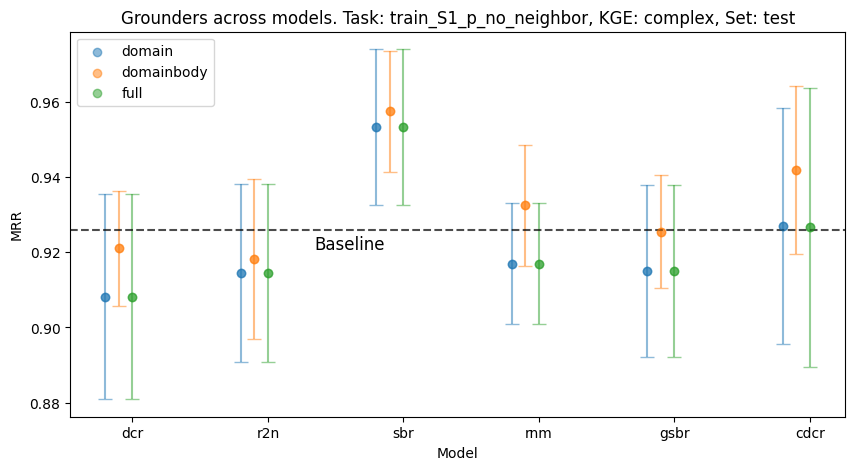

Grounder     domain  domainbody    full
Model_name                             
cdcr         0.9148      0.9289  0.9165
dcr          0.9185      0.9159  0.9212
gsbr         0.9187      0.9167  0.9187
no_reasoner  0.9186      0.9186  0.9186
r2n          0.9183      0.9167  0.9183
rnm          0.9244      0.9207  0.9244
sbr          0.9528      0.9679  0.9528


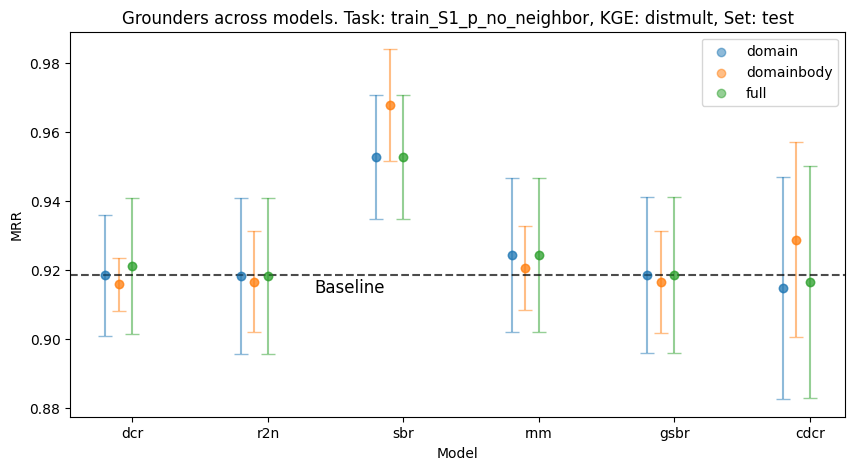

Grounder     domain  domainbody    full
Model_name                             
cdcr         0.7342      0.7079  0.7311
dcr          0.7682      0.7669  0.7682
gsbr         0.7398      0.7155  0.7398
no_reasoner  0.7293      0.7293  0.7293
r2n          0.7306      0.7211  0.7306
rnm          0.7380      0.7224  0.7380
sbr          0.7401      0.7127  0.7401


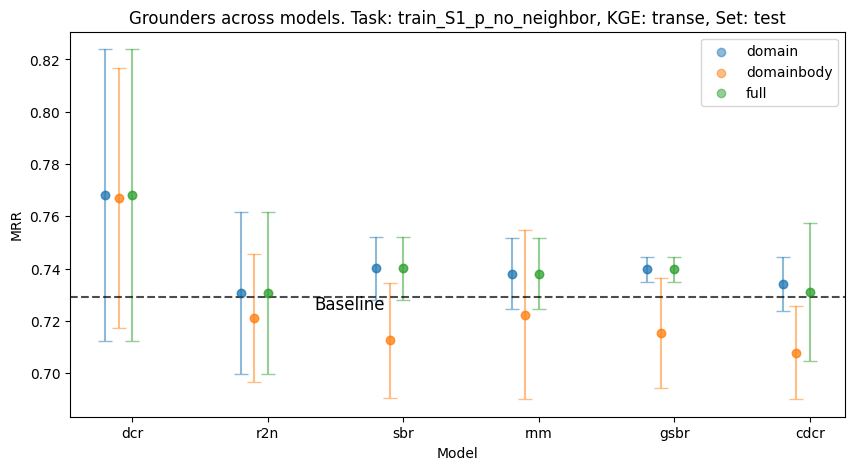

Grounder        domain  domainbody       full
Model_name                                   
cdcr         38.580872   28.401116  39.679936
dcr          26.635564   24.717993  27.470032
gsbr         20.168084   19.212295  20.726722
no_reasoner  18.712290   19.419352  18.572739
r2n          28.608504   22.889426  29.226821
rnm          19.387516   18.875618  19.791149
sbr          19.244819   16.692557  19.721573


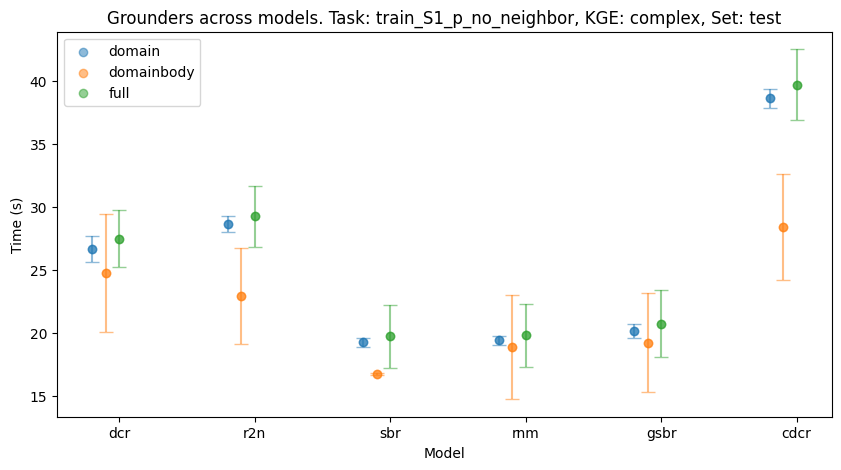

Grounder        domain  domainbody       full
Model_name                                   
cdcr         35.534146   25.949830  35.142126
dcr          23.530858   20.367238  24.415215
gsbr         17.440855   14.479284  18.453099
no_reasoner  15.988257   17.279842  16.283953
r2n          25.679049   18.228705  25.900484
rnm          16.072651   16.328681  16.228065
sbr          16.320183   16.228066  17.401174


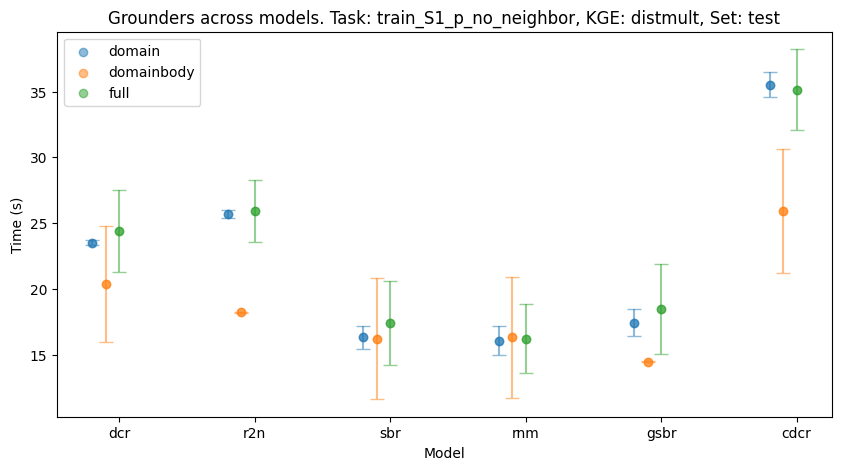

Grounder        domain  domainbody       full
Model_name                                   
cdcr         36.431364   27.028564  35.871129
dcr          24.099767   18.809344  25.528441
gsbr         17.578889   17.817080  18.042311
no_reasoner  17.460561   15.647155  17.382345
r2n          26.586021   21.716851  26.789028
rnm          17.481595   14.566724  18.670242
sbr          17.164535   17.048178  16.842520


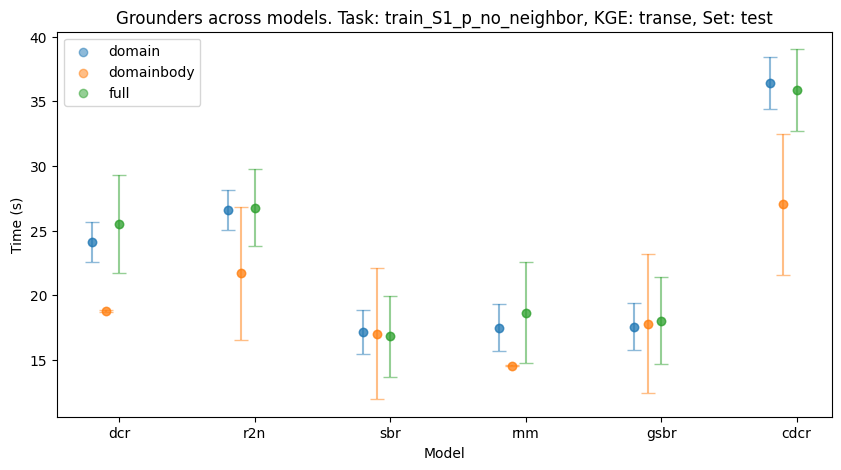

In [26]:
# Table 1: rows:grounder, cols:Model, values: mrr
root_dir = "C:\\Users\\rodri\\Downloads\\PhD\\Review_grounders\\keras_ns_grounders\\experiments\\countries\\hparamsearch\\"
step = 'test'
cols = 'Grounder'
rows = 'Model_name'
metric = step+'_task_mrr'
models = ['dcr','r2n','sbr','rnm','gsbr','cdcr']
baseline_model = 'no_reasoner'
baseline_metric = step+'_concept_mrr'
tasks =  ['train_S1_p_no_neighbor'] #  ['train_S1_p','train_S2_p','train_S3_p'] #
metrics = [step+'_task_mrr','Time']
metric_names = {step+'_task_mrr':'MRR', 'Time':'Time (s)'}
for task in tasks:
    for metric in metrics:
        for KGE in ['complex', 'distmult', 'transe']:
            # filter the df
            results = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
            # take only the columns grounder, model, test_task_mrr, test_concept_mrr
            results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
            # put the model_name as colums
            results = results.pivot(index=rows, columns=cols, values=metric)

            if metric == step+'_task_mrr':
                # in the column no_reasoner, put the values of the columnstep+ _concept_mrr
                substitute = df.loc[(df['Task'] == task) & (df['KGE'] == KGE) & (df['Model_name'] == baseline_model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)][[cols,rows,baseline_metric]]
                substitute = substitute.pivot(index=rows, columns=cols, values=baseline_metric)
                # substitute the values in the table
                results.loc[baseline_model] = substitute.loc[baseline_model]
            df_mean, df_std = split_df(results)
            print(df_mean)
            # Remove no reasoner and include a line where it is written baseline
            plt.figure(figsize=(10,5))
            for i,grounder in enumerate(df_mean.columns):
                plt.scatter(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], label=grounder, alpha=0.5)
                plt.errorbar(np.arange(len(df_mean.loc[models].index))+0.1*i, df_mean.loc[models][grounder], yerr=df_std.loc[models][grounder], fmt='o',capsize=5, alpha=0.5)
            if metric == step+'_task_mrr':
                plt.axhline(y=df_mean.loc[baseline_model].values[0], color='black', linestyle='--', alpha=.7)  # Change color and linestyle as desired
                plt.text(1.8, df_mean.loc[baseline_model].values[0]-0.005, 'Baseline', color='black', fontsize=12, ha='center')
                # print(df_mean.loc[baseline_model].values[0])
            plt.legend()
            plt.xticks(np.arange(len(df_mean.loc[models].index))+0.2, df_mean.loc[models].index.tolist(), rotation=0)
            plt.ylabel(metric_names[metric])
            plt.xlabel('Model')
            plt.title(f'Grounders across models. Task: {task}, KGE: {KGE}, Set: {step}')
            plt.show()
            # SAVE THE FIGURE
            # plt.savefig(root_dir+'figures\\Grounders_across_models__'+'Task_'+task+'_Metric_'+metric+'_KGE_'+KGE+'.png', dpi=300, bbox_inches='tight')  

In [10]:
# cols = 'Grounder'
# rows = 'KGE'
# metric = 'test_task_mrr'
# baseline_model = 'no_reasoner'
# baseline_metric = 'test_concept_mrr'
# for metric in ['test_task_mrr', 'Time']:
#     for model in df['Model_name'].unique():
#         if model !='no_reasoner':
#             # filter the df
#             results = df.loc[ (df['Model_name'] == model) & (df['WeightLoss_Task'] == 0.5) & (df['Reasoner_depth'] == 1) & (df['EmbedSize'] == 100)].copy()
#             # take only the columns grounder, model, test_task_mrr, test_concept_mrr
#             results = results[[cols, rows, metric]]#, 'test_concept_mrr']]
#             # put the model_name as colums
#             results = results.pivot(index=rows, columns=cols, values=metric)

#             df_mean, df_std = split_df(results)
#             # Remove no reasoner and include a line where it is written baseline
#             plt.figure(figsize=(10,5))
#             for i,grounder in enumerate(df_mean.columns):
#                 plt.scatter(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], label=grounder, alpha=0.5)
#                 plt.errorbar(np.arange(len(df_mean.index))+0.1*i, df_mean[grounder], yerr=df_std[grounder], fmt='o',capsize=5, alpha=0.5)
#             plt.legend()
#             plt.xticks(np.arange(len(df_mean.index))+0.1*i, df_mean.index.tolist(), rotation=0)
#             plt.ylabel('MRR test')
#             plt.xlabel('KGE')
#             plt.title(f'Grounders across KGEs for model {model}')
#             plt.show()
#             # plt.savefig(root_dir+'figures\\Grounders_across_KGE___Model_'+model+'.png', dpi=300, bbox_inches='tight')  